# DocVQA — Exploratory Data Analysis
**Project:** Multimodal RAG Educational Assistant  
**Student:** Omar Dahab — 23100704  
**Dataset:** DocVQA (Document Visual Question Answering)  

This notebook covers:
1. Dataset loading & overview
2. Class balance analysis
3. Preprocessing issues discovery
4. Preprocessing implementation
5. Summary statistics

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
from datasets import load_dataset, Dataset
from pathlib import Path
import re
import warnings
warnings.filterwarnings('ignore')

EDA_DIR = Path('../data/eda')
EDA_DIR.mkdir(exist_ok=True, parents=True)

# Plot styling
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PALETTE = ['#1D9E75', '#7F77DD', '#D85A30', '#F5A623', '#4A90D9']

print('Imports OK')

Imports OK


## 1. Load Dataset

In [17]:
print('Loading DocVQA from HuggingFace')
ds_train = load_dataset('lmms-lab/DocVQA', 'DocVQA', split='validation', streaming=True)


ds_train = Dataset.from_list(list(ds_train.take(500)))


print(f'Train samples : {len(ds_train)}')
print(f'\nFeatures: {list(ds_train.features.keys())}')

Loading DocVQA from HuggingFace
Train samples : 500

Features: ['questionId', 'question', 'question_types', 'image', 'docId', 'ucsf_document_id', 'ucsf_document_page_no', 'answers', 'data_split']


In [18]:
# Peek at one sample
sample = ds_train[0]
print('Question :', sample['question'])
print('Answers  :', sample['answers'])
print('Doc ID   :', sample.get('ucsf_document_id', 'N/A'))

Question : What is the ‘actual’ value per 1000, during the year 1975?
Answers  : ['0.28']
Doc ID   : pybv0228


In [19]:
# Convert to DataFrame for easier analysis
records = []
for item in ds_train:
    primary_answer = item['answers'][0] if item['answers'] else ''
    records.append({
        'question'       : item['question'],
        'answer'         : primary_answer,
        'num_answers'    : len(item['answers']),
        'question_id'    : item.get('questionId', ''),
    })

df = pd.DataFrame(records)
print(df.shape)
df.head()

(500, 4)


,question,answer,num_answers,question_id
0,"What is the ‘actual’ value per 1000, during th...",0.28,1,49153
1,What is name of university?,university of california,3,24580
2,What is the name of the company?,itc limited,2,57349
3,Where is the university located ?,san diego,2,24581
4,To whom is the document sent?,Paul,1,24582


## 2. Class Balance Analysis

In [20]:
# Answer length bucketing 
df['answer_len'] = df['answer'].apply(lambda x: len(str(x).split()))

def classify_answer(n):
    if n == 0:  return 'empty'
    if n == 1:  return 'single word'
    if n <= 5:  return 'short phrase'
    if n <= 15: return 'sentence'
    return 'long answer'

df['answer_type'] = df['answer_len'].apply(classify_answer)

counts = df['answer_type'].value_counts()
print("Answer type distribution :")
for label, count in counts.items():
    print(f'  {label:15s} {count:4d} ')

Answer type distribution :
  short phrase     237 
  single word      234 
  sentence          29 


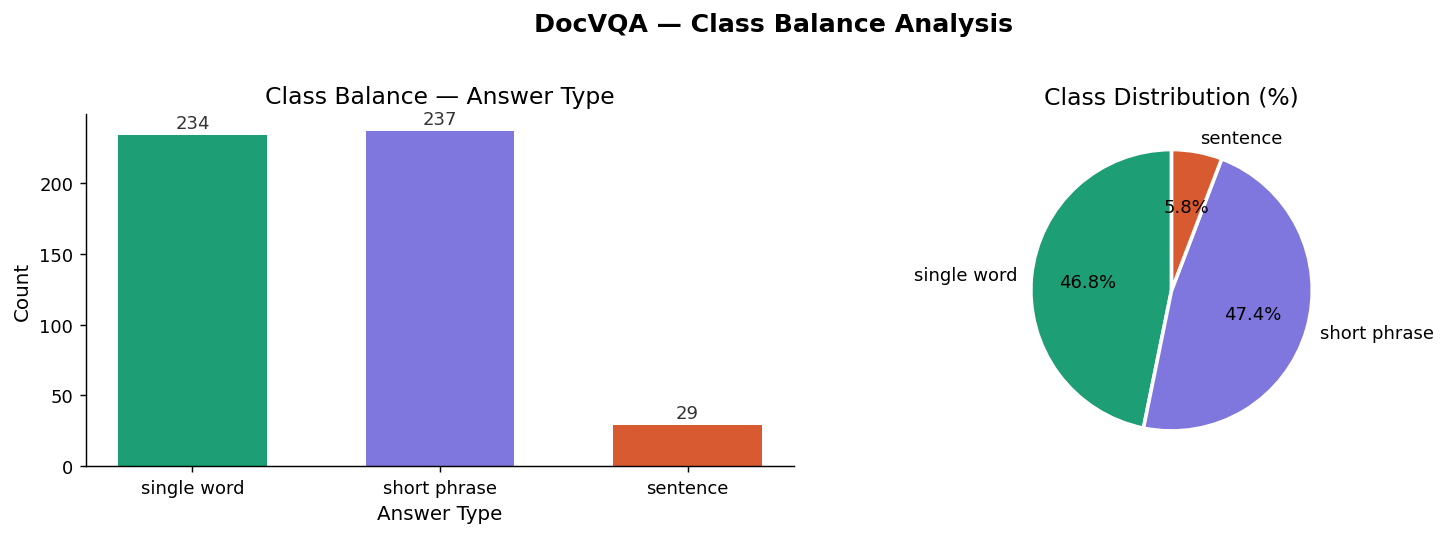

Saved → class_balance.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart — class counts
order = ['single word', 'short phrase', 'sentence', 'long answer', 'empty']
order = [o for o in order if o in counts.index]
bars = axes[0].bar(order, [counts.get(o, 0) for o in order],
                   color=PALETTE[:len(order)], edgecolor='none', width=0.6)
axes[0].set_title('Class Balance — Answer Type')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Answer Type')
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 2, str(int(h)),
                 ha='center', va='bottom', fontsize=10, color='#333')

# Pie chart — proportions
axes[1].pie([counts.get(o, 0) for o in order], labels=order,
            colors=PALETTE[:len(order)], autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Distribution (%)')

plt.suptitle('DocVQA — Class Balance Analysis', fontsize=14, fontweight='600', y=1.02)
plt.tight_layout()
plt.savefig(EDA_DIR / 'class_balance.png', bbox_inches='tight')
plt.show()
print('Saved → class_balance.png')

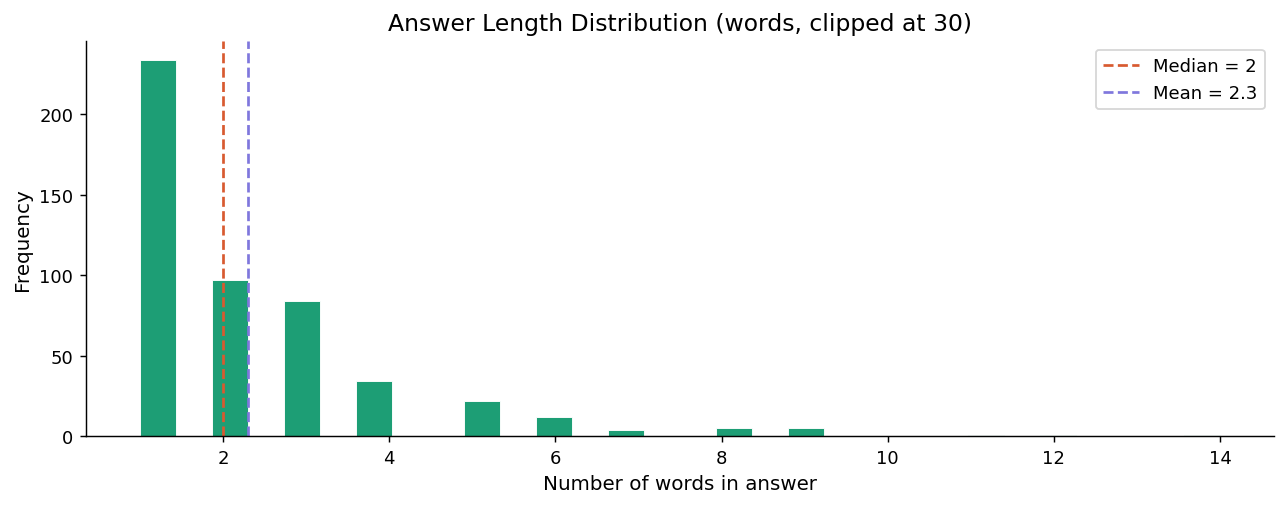

Saved → answer_length_dist.png


In [22]:
# Answer length distribution histogram
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['answer_len'].clip(upper=30), bins=30,
        color=PALETTE[0], edgecolor='white', linewidth=0.5)
ax.set_title('Answer Length Distribution (words, clipped at 30)')
ax.set_xlabel('Number of words in answer')
ax.set_ylabel('Frequency')
ax.axvline(df['answer_len'].median(), color=PALETTE[2], linestyle='--',
           linewidth=1.5, label=f'Median = {df["answer_len"].median():.0f}')
ax.axvline(df['answer_len'].mean(), color=PALETTE[1], linestyle='--',
           linewidth=1.5, label=f'Mean = {df["answer_len"].mean():.1f}')
ax.legend()
plt.tight_layout()
plt.savefig(EDA_DIR / 'answer_length_dist.png', bbox_inches='tight')
plt.show()
print('Saved → answer_length_dist.png')

## 3. Preprocessing Issues Discovery

In [23]:

print('PREPROCESSING ISSUES AUDIT')


total = len(df)

# Issue 1 — Empty answers
empty = df[df['answer'].str.strip() == ''].shape[0]
print(f'\n[1] Empty answers          : {empty:4d} / {total}  ({empty/total*100:.1f}%)')

# Issue 2 — Non-ASCII characters (OCR noise)
non_ascii = df[df['answer'].str.contains(r'[^\x00-\x7F]', na=False)].shape[0]
print(f'[2] Non-ASCII (OCR noise)  : {non_ascii:4d} / {total}  ({non_ascii/total*100:.1f}%)')

# Issue 3 — Outlier answers (very long)
outliers = df[df['answer_len'] > 20].shape[0]
print(f'[3] Outliers (>20 words)   : {outliers:4d} / {total}  ({outliers/total*100:.1f}%)')

# Issue 4 — Answers with only numbers (may be noisy)
numeric_only = df[df['answer'].str.match(r'^[\d\s\.\,\%]+$', na=False)].shape[0]
print(f'[4] Numeric-only answers   : {numeric_only:4d} / {total}  ({numeric_only/total*100:.1f}%)')

# Issue 5 — Duplicate answers
dupes = df.duplicated(subset=['answer']).sum()
print(f'[5] Duplicate answers      : {dupes:4d} / {total}  ({dupes/total*100:.1f}%)')

# Issue 6 — Questions with multiple different answers (ambiguous)
multi = df[df['num_answers'] > 1].shape[0]
print(f'[6] Multi-answer questions : {multi:4d} / {total}  ({multi/total*100:.1f}%)')

# Issue 7 — Extra whitespace
whitespace = df[df['answer'].str.contains(r'\s{2,}', na=False)].shape[0]
print(f'[7] Extra whitespace       : {whitespace:4d} / {total}  ({whitespace/total*100:.1f}%)')


PREPROCESSING ISSUES AUDIT

[1] Empty answers          :    0 / 500  (0.0%)
[2] Non-ASCII (OCR noise)  :    0 / 500  (0.0%)
[3] Outliers (>20 words)   :    0 / 500  (0.0%)
[4] Numeric-only answers   :  107 / 500  (21.4%)
[5] Duplicate answers      :   43 / 500  (8.6%)
[6] Multi-answer questions :  253 / 500  (50.6%)
[7] Extra whitespace       :    1 / 500  (0.2%)


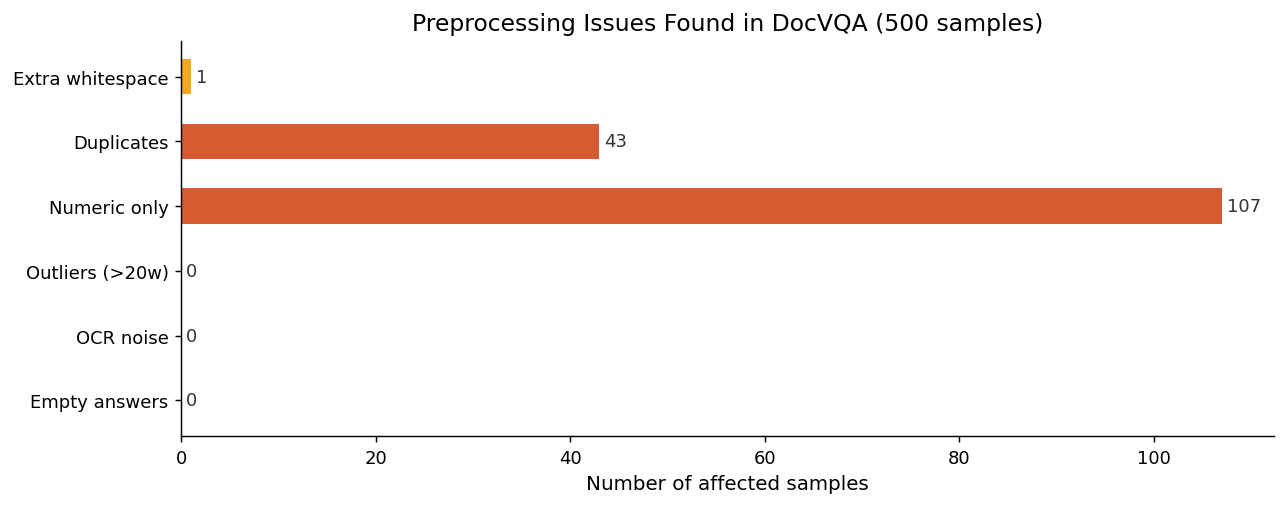

Saved → preprocessing_issues.png


In [24]:
# Visualise the issues
issues = {
    'Empty answers'     : empty,
    'OCR noise'         : non_ascii,
    'Outliers (>20w)'   : outliers,
    'Numeric only'      : numeric_only,
    'Duplicates'        : dupes,
    'Extra whitespace'  : whitespace,
}

fig, ax = plt.subplots(figsize=(10, 4))
colors = [PALETTE[2] if v > 10 else PALETTE[3] if v > 0 else PALETTE[0]
          for v in issues.values()]
bars = ax.barh(list(issues.keys()), list(issues.values()),
               color=colors, edgecolor='none', height=0.55)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.5, bar.get_y() + bar.get_height()/2,
            str(int(w)), va='center', fontsize=10, color='#333')
ax.set_title('Preprocessing Issues Found in DocVQA (500 samples)')
ax.set_xlabel('Number of affected samples')
plt.tight_layout()
plt.savefig(EDA_DIR / 'preprocessing_issues.png', bbox_inches='tight')
plt.show()
print('Saved → preprocessing_issues.png')

## 4. Preprocessing Implementation


In [25]:
def clean_answer(text: str) -> str:
    """Fix all identified preprocessing issues in one function."""
    if not isinstance(text, str):
        return ''
    # Fix 1 — remove non-ASCII (OCR noise)
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    # Fix 2 — collapse extra whitespace
    text = re.sub(r'\s+', ' ', text)
    # Fix 3 — strip leading/trailing whitespace
    text = text.strip()
    # Fix 4 — lowercase for consistency
    text = text.lower()
    return text


def clean_question(text: str) -> str:
    """Clean question text."""
    if not isinstance(text, str):
        return ''
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def preprocess_df(df: pd.DataFrame) -> pd.DataFrame:
    """Full preprocessing pipeline — returns cleaned dataframe."""
    df = df.copy()

    # Apply cleaning
    df['answer_clean']   = df['answer'].apply(clean_answer)
    df['question_clean'] = df['question'].apply(clean_question)

    # Remove empty answers
    before = len(df)
    df = df[df['answer_clean'].str.len() > 0]
    print(f'Removed {before - len(df)} empty answers')

    # Remove extreme outliers (answers > 20 words likely OCR errors)
    df['answer_clean_len'] = df['answer_clean'].apply(lambda x: len(x.split()))
    before = len(df)
    df = df[df['answer_clean_len'] <= 20]
    print(f'Removed {before - len(df)} outlier answers (>20 words)')

    # Drop duplicates
    before = len(df)
    df = df.drop_duplicates(subset=['question_clean', 'answer_clean'])
    print(f'Removed {before - len(df)} duplicate rows')

    df = df.reset_index(drop=True)
    print(f'\nFinal dataset size: {len(df)} samples ')
    return df


df_clean = preprocess_df(df)
df_clean.head()

Removed 0 empty answers
Removed 0 outlier answers (>20 words)
Removed 9 duplicate rows

Final dataset size: 491 samples 


,question,answer,num_answers,question_id,answer_len,answer_type,answer_clean,question_clean,answer_clean_len
0,"What is the ‘actual’ value per 1000, during th...",0.28,1,49153,1,single word,0.28,"What is the actual value per 1000, during the ...",1
1,What is name of university?,university of california,3,24580,3,short phrase,university of california,What is name of university?,3
2,What is the name of the company?,itc limited,2,57349,2,short phrase,itc limited,What is the name of the company?,2
3,Where is the university located ?,san diego,2,24581,2,short phrase,san diego,Where is the university located ?,2
4,To whom is the document sent?,Paul,1,24582,1,single word,paul,To whom is the document sent?,1


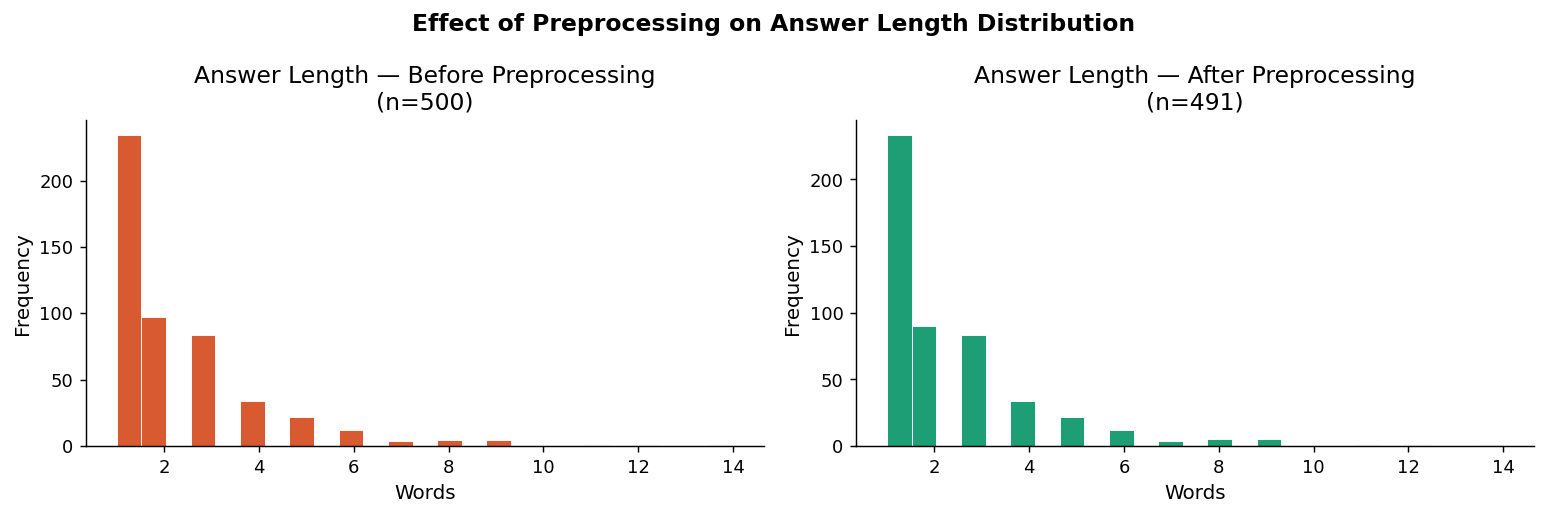

Saved → before_after_preprocessing.png


In [26]:
# Before vs after comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, data, title in zip(axes,
                            [df, df_clean],
                            ['Before Preprocessing', 'After Preprocessing']):
    lens = data['answer_clean_len'] if 'answer_clean_len' in data.columns else data['answer_len']
    ax.hist(lens.clip(upper=25), bins=25, color=PALETTE[0] if 'After' in title else PALETTE[2],
            edgecolor='white', linewidth=0.5)
    ax.set_title(f'Answer Length — {title}\n(n={len(data)})')
    ax.set_xlabel('Words')
    ax.set_ylabel('Frequency')

plt.suptitle('Effect of Preprocessing on Answer Length Distribution',
             fontsize=13, fontweight='600')
plt.tight_layout()
plt.savefig(EDA_DIR / 'before_after_preprocessing.png', bbox_inches='tight')
plt.show()
print('Saved → before_after_preprocessing.png')

## 5. Summary Statistics

In [27]:
print('FINAL DATASET SUMMARY')
print(f'Total samples (clean) : {len(df_clean)}')
print(f'Unique questions      : {df_clean["question_clean"].nunique()}')
print(f'Unique answers        : {df_clean["answer_clean"].nunique()}')
print()
print('Answer length stats (words):')
print(df_clean['answer_clean_len'].describe().round(2).to_string())
print()
print('Answer type distribution (cleaned):')
df_clean['answer_type'] = df_clean['answer_clean_len'].apply(classify_answer)
type_counts = df_clean['answer_type'].value_counts()
for t, c in type_counts.items():
    print(f'  {t:15s}: {c:4d}  ({c/len(df_clean)*100:.1f}%)'+"\n")
print('EDA complete — all charts saved to folder')

FINAL DATASET SUMMARY
Total samples (clean) : 491
Unique questions      : 474
Unique answers        : 451

Answer length stats (words):
count    491.00
mean       2.30
std        1.83
min        1.00
25%        1.00
50%        2.00
75%        3.00
max       14.00

Answer type distribution (cleaned):
  single word    :  233  (47.5%)

  short phrase   :  229  (46.6%)

  sentence       :   29  (5.9%)

EDA complete — all charts saved to folder


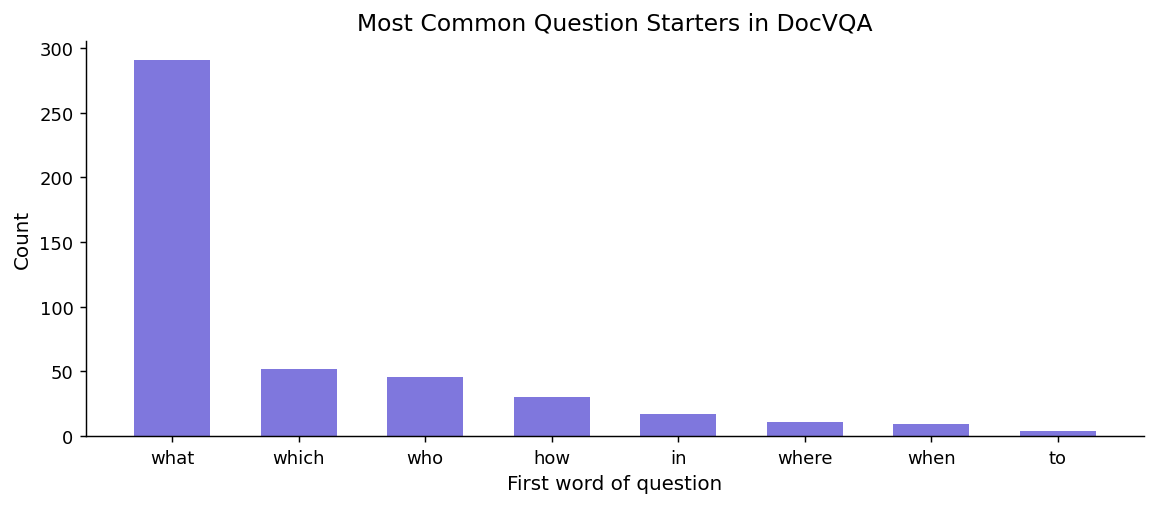

Saved → question_types.png


In [28]:
# Question word frequency — what types of questions are asked?
question_starts = df_clean['question_clean'].str.split().str[0].str.lower()
q_counts = question_starts.value_counts().head(8)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(q_counts.index, q_counts.values, color=PALETTE[1], edgecolor='none', width=0.6)
ax.set_title('Most Common Question Starters in DocVQA')
ax.set_ylabel('Count')
ax.set_xlabel('First word of question')
plt.tight_layout()
plt.savefig(EDA_DIR / 'question_types.png', bbox_inches='tight')
plt.show()
print('Saved → question_types.png')

In [29]:
# Export cleaned dataset to CSV for use in the pipeline
df_clean[['question_clean', 'answer_clean']].to_csv(EDA_DIR / 'docvqa_clean.csv', index=False)
print('Exported → docvqa_clean.csv')

Exported → docvqa_clean.csv
